# Trabajo Práctico N°1
## Problema 2: Regresión

Integrantes: Sebastian Palacio, Juana Chies Doumecq

**Objetivo:**

Construir un modelo de red neuronal que prediga el valor numérico de la rentabilidad (Profit) de una transacción comercial a partir de las características del pedido.

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import copy

from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import KNNImputer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [117]:
base_path = os.path.join("datasets", "problema3")
df = pd.read_csv(os.path.join(base_path, 'Sample - Superstore.csv'), encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

###  Análisis Exploratorio de Datos (EDA)

**Ingeniería de características**

In [119]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

for col, prefix in [('Order Date', 'order'), ('Ship Date', 'ship')]:
    df[f'{prefix}_year']    = df[col].dt.year
    df[f'{prefix}_month']   = df[col].dt.month
    df[f'{prefix}_dow']     = df[col].dt.dayofweek
    df[f'{prefix}_quarter'] = df[col].dt.quarter

# Demora en días
df['ship_delay'] = (df['Ship Date'] - df['Order Date']).dt.days

# Eliminamos columnas de fecha originales
df.drop(columns=['Order Date', 'Ship Date'], inplace=True)

In [120]:
cols_to_drop = [
    'Row ID', 'Order ID', 'Customer ID',
    'Customer Name', 'Product ID', 'Product Name',
    'Country', 'City', 'Postal Code',
]

df.drop(columns=cols_to_drop, inplace=True)

In [121]:
print("Columnas tras feature engineering:")
print(df.columns.tolist())

Columnas tras feature engineering:
['Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'order_year', 'order_month', 'order_dow', 'order_quarter', 'ship_year', 'ship_month', 'ship_dow', 'ship_quarter', 'ship_delay']


**División cruzada train - test**

In [122]:
X = df.drop(columns='Profit')
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Validation size: {len(X_val)}")

Train size: 6396
Test size: 1999
Validation size: 1599


**Visualización de datos** (previo a la imputación)

In [123]:
numerical_cols = ['Sales', 'Quantity', 'Discount']
show_num = X_train[numerical_cols].copy()
show_num['Profit'] = y_train.values

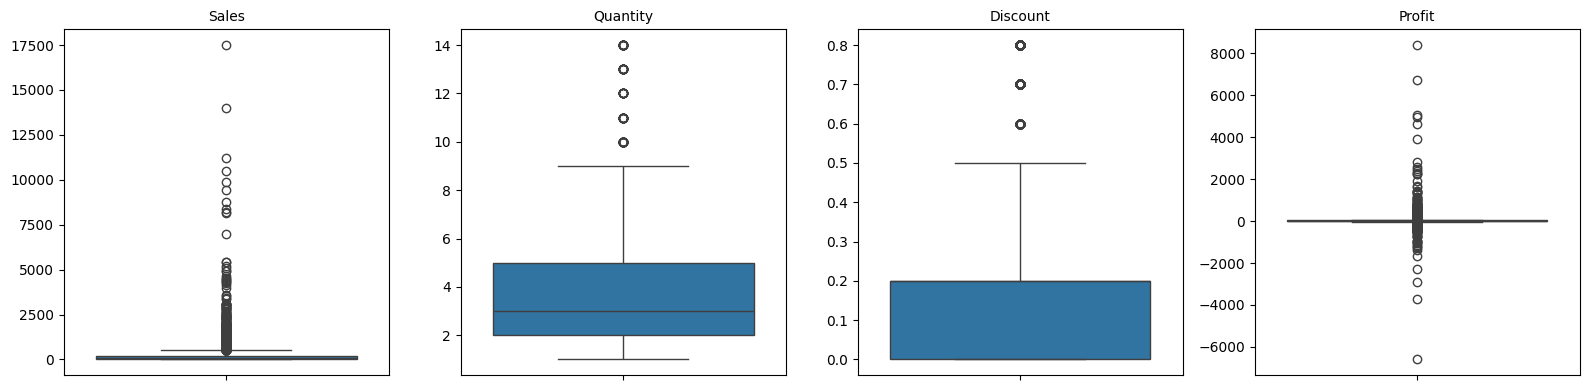

In [124]:
cols = 4 
num_vars = len(show_num.columns)
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4*rows))
axes = axes.flatten()

for i, var in enumerate(show_num.columns): 
    sns.boxplot(
        data=show_num,
        y=var, 
        ax=axes[i]
    )
    axes[i].set_title(f'{var}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

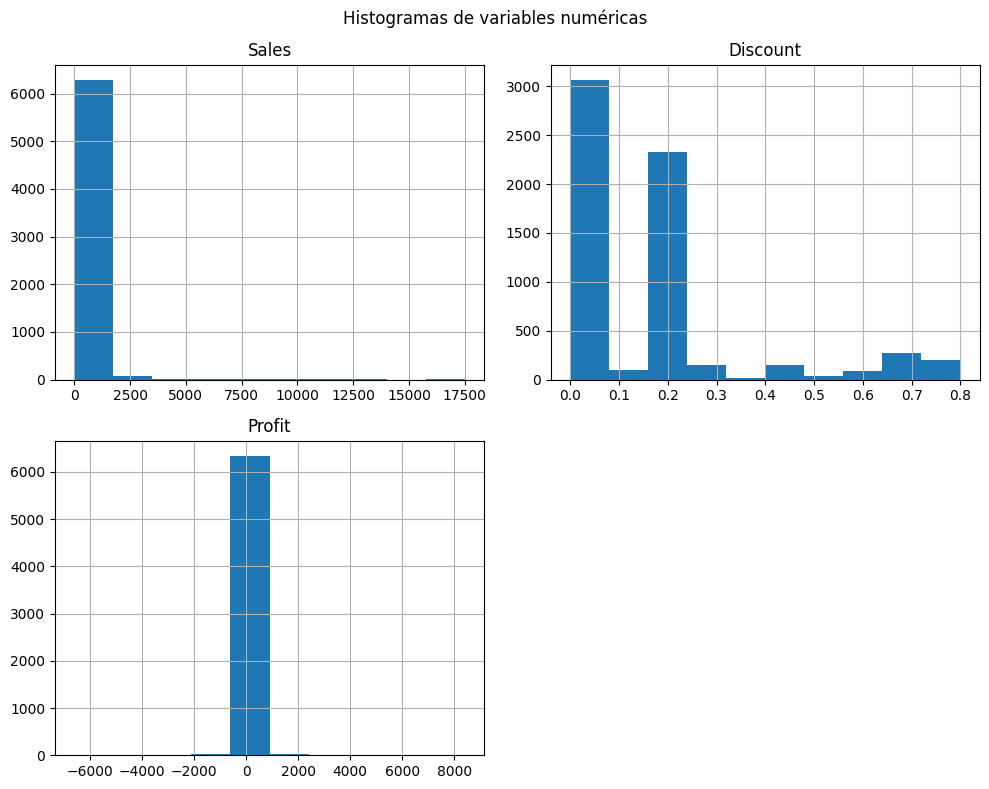

In [125]:
show_num[['Sales', 'Discount', 'Profit']].hist(figsize=(10,8))
plt.suptitle("Histogramas de variables numéricas")
plt.tight_layout()
plt.show()

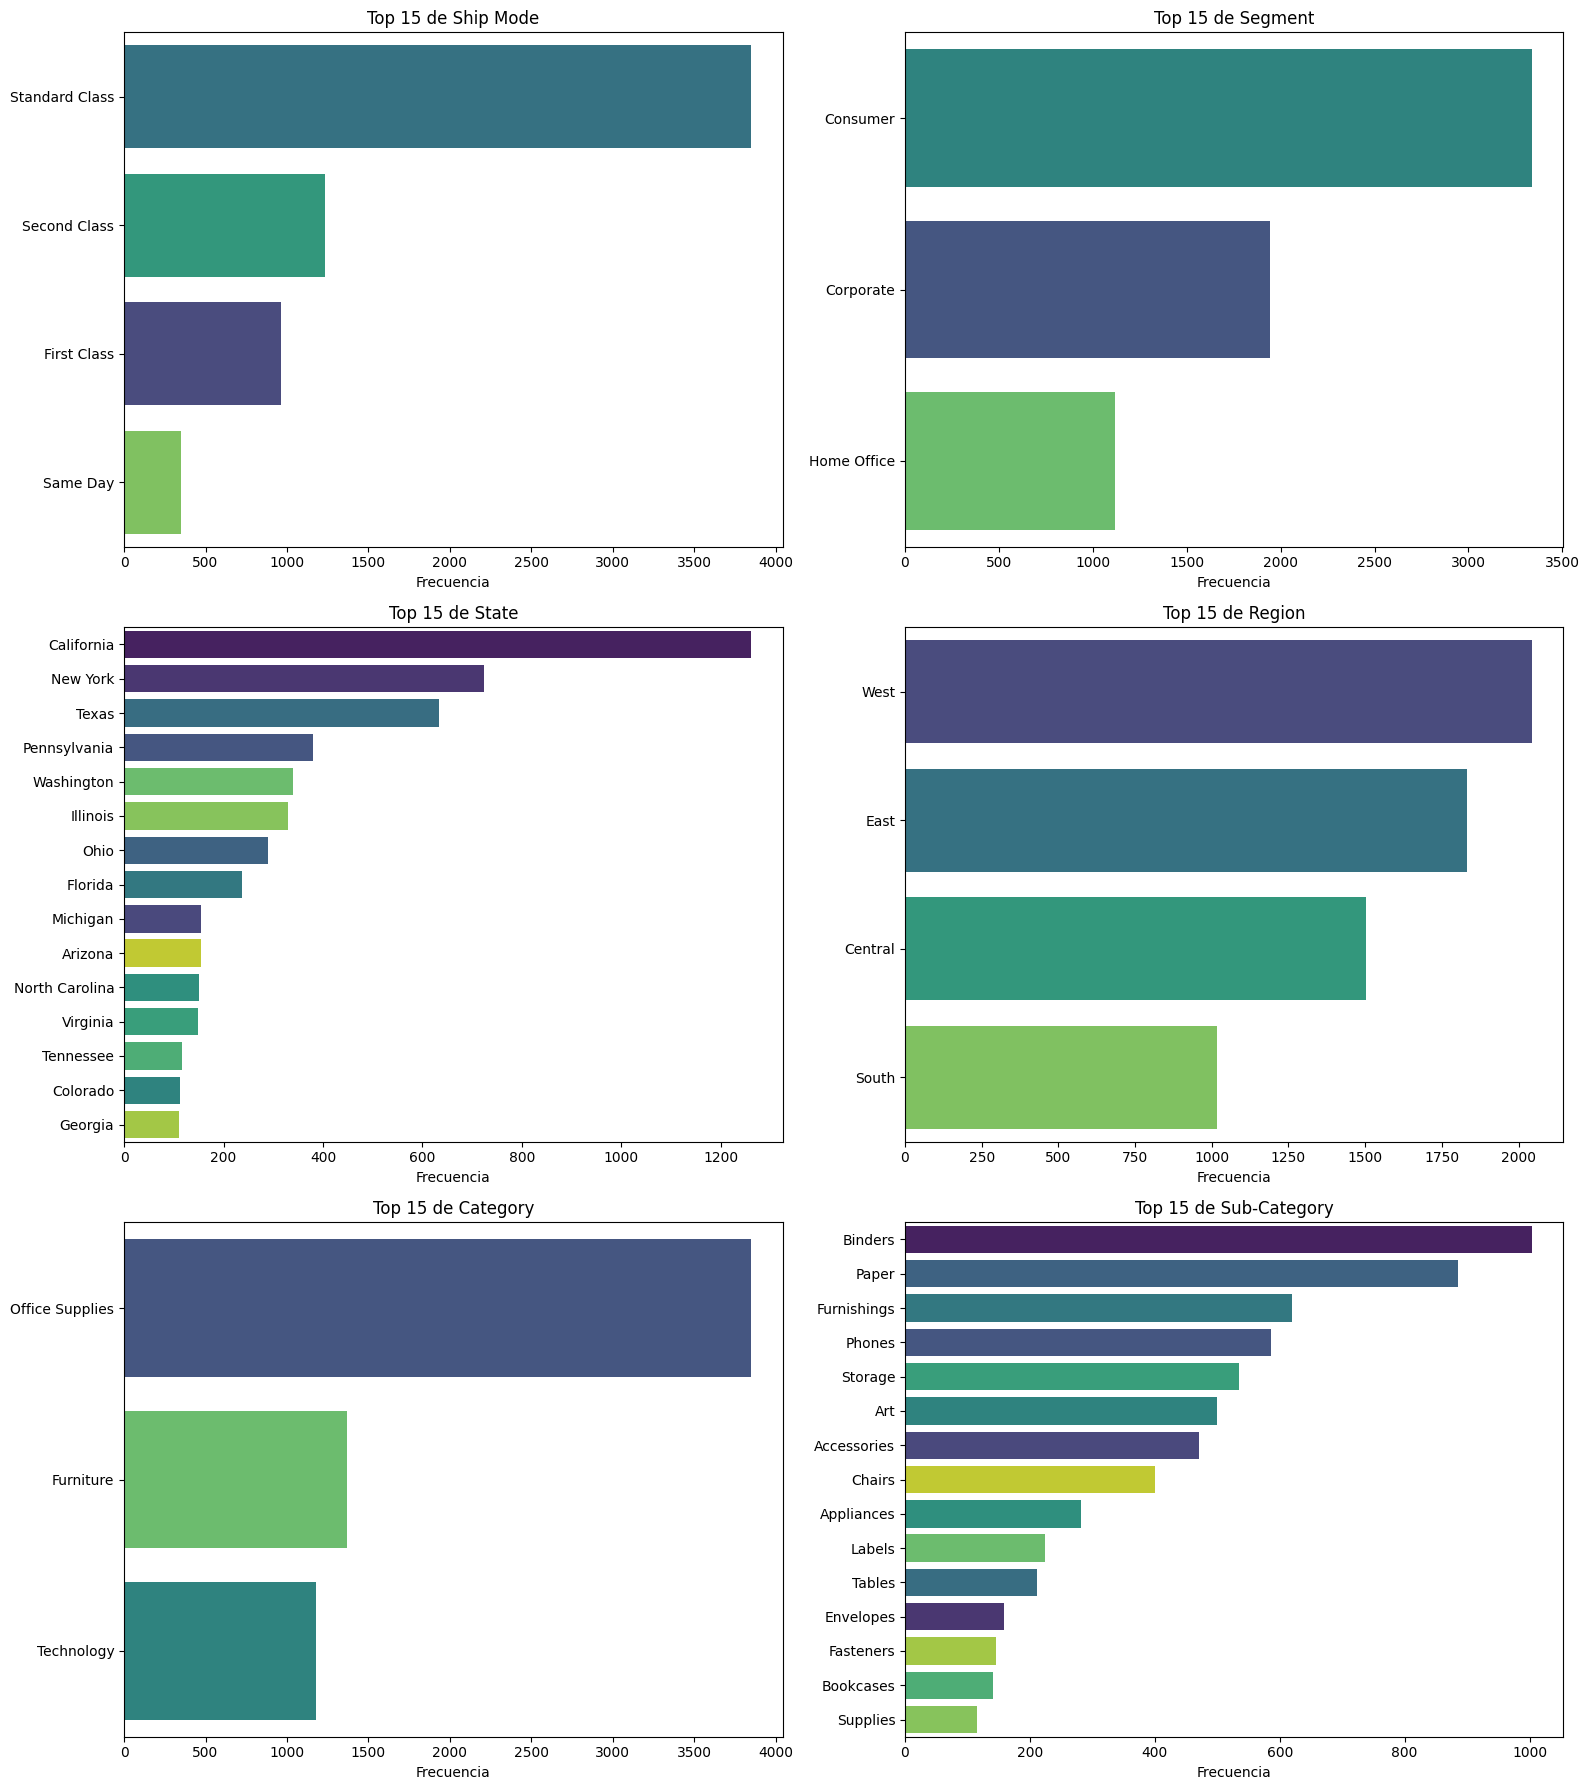

In [126]:
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
show_cat = X_train[categorical_cols].copy()

n_cols = 2 
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    top_n = show_cat[col].value_counts().head(15)
    
    sns.countplot(
        data=show_cat[show_cat[col].isin(top_n.index)], 
        y=col, 
        ax=axes[i], 
        order=top_n.index,
        palette='viridis',
        hue=col,
        legend=False
    )
    
    axes[i].set_title(f'Top 15 de {col}', fontsize=12)
    axes[i].set_xlabel('Frecuencia')
    axes[i].set_ylabel('')

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Análisis y decisión sobre datos faltantes y outliers**

In [127]:
X_test.isna().sum()

Ship Mode        0
Segment          0
State            0
Region           0
Category         0
Sub-Category     0
Sales            0
Quantity         0
Discount         0
order_year       0
order_month      0
order_dow        0
order_quarter    0
ship_year        0
ship_month       0
ship_dow         0
ship_quarter     0
ship_delay       0
dtype: int64

Sales y Profit: Es totalmente normal ver valores extremos aquí. Hay ventas masivas a empresas o devoluciones que generan grandes pérdidas (Profit negativo).

Decisión: No te conviene eliminarlos, ya que el modelo debe aprender a predecir también esos casos importantes. Sin embargo, para una Red Neuronal (MLP), estos valores pueden "marear" al optimizador. En lugar de borrarlos, te sugiero usar RobustScaler o aplicar una transformación para suavizar la escala (como np.log1p para Sales, aunque para Profit es más complejo por los negativos).

Quantity: Generalmente varía entre 1 y 14. Los valores altos no son "outliers" en el sentido de error, sino simplemente compras grandes. No requieren tratamiento especial más allá del escalado.

Discount: Ojo acá. El descuento suele estar entre 0 y 0.8 (80%). Si ves valores fuera de ese rango, podrían ser errores. Pero si están en rango, son datos legítimos.

**Codificación de variables categóricas**

In [ ]:
ohe_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

te_cols = ['State']

# --- One-Hot Encoding ---
X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=False, dtype=float)
X_test  = pd.get_dummies(X_test,  columns=ohe_cols, drop_first=False, dtype=float)
X_val   = pd.get_dummies(X_val,   columns=ohe_cols, drop_first=False, dtype=float)

# --- Target Encoding ---
te = TargetEncoder(cols=te_cols, smoothing=10)
X_train[te_cols] = te.fit_transform(X_train[te_cols], y_train)
X_test[te_cols]  = te.transform(X_test[te_cols])
X_val[te_cols]   = te.transform(X_val[te_cols])

**Visualización de datos** (posterior a la imputación)

In [129]:
numerical_cols = ['Sales', 'Quantity', 'Discount']
show_num = X_train[numerical_cols].copy()
show_num['Profit'] = y_train.values

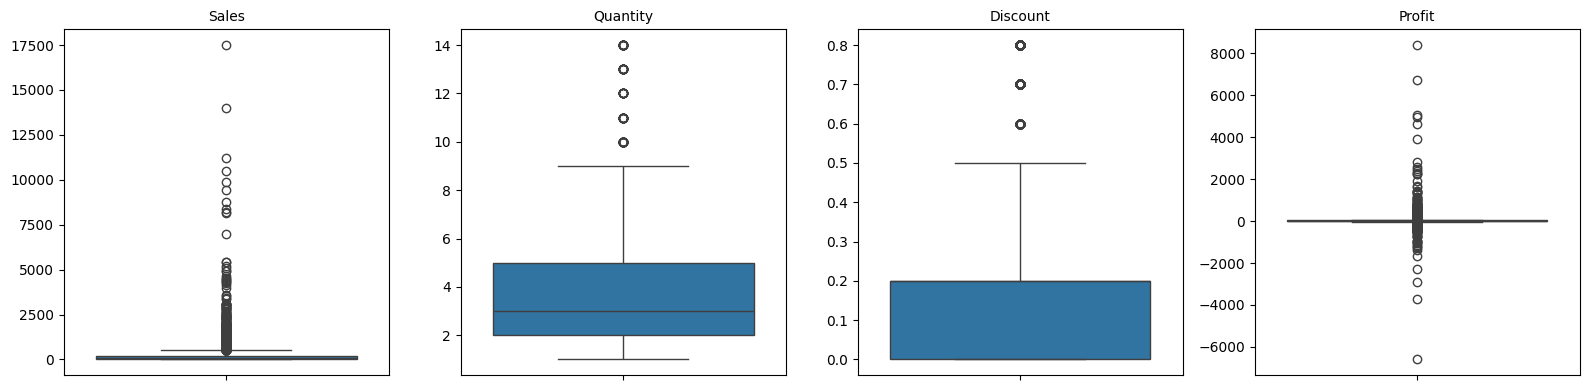

In [130]:
cols = 4 
num_vars = len(show_num.columns)
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4*rows))
axes = axes.flatten()

for i, var in enumerate(show_num.columns): 
    sns.boxplot(
        data=show_num,
        y=var, 
        ax=axes[i]
    )
    axes[i].set_title(f'{var}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

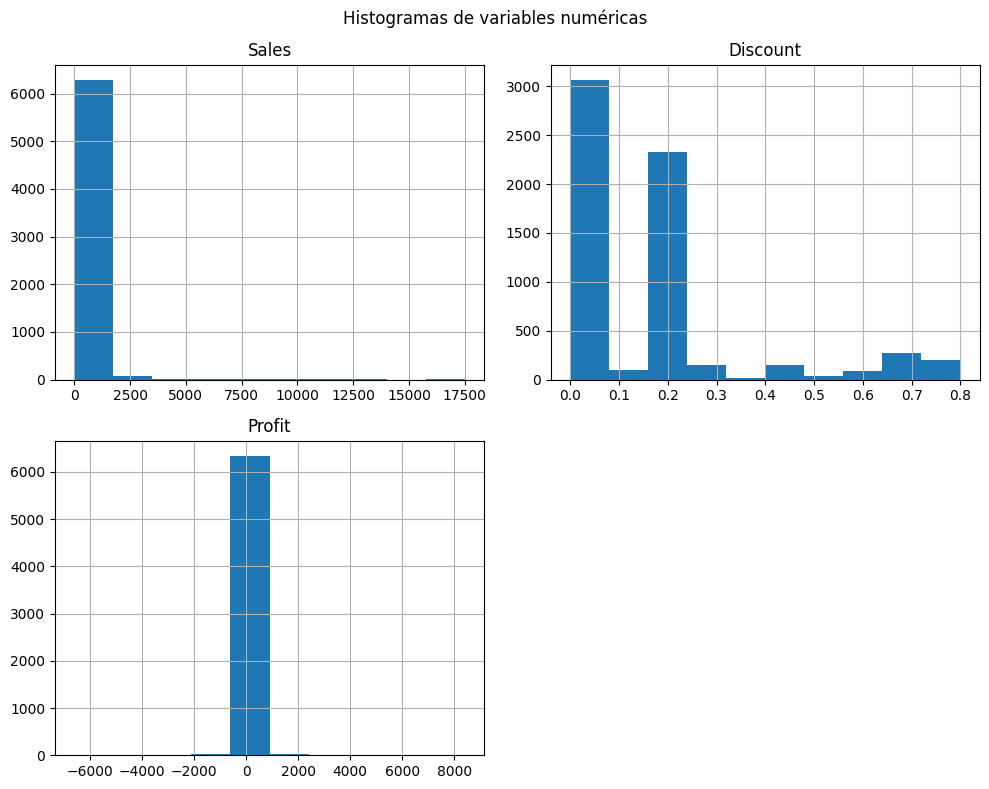

In [131]:
show_num[['Sales', 'Discount', 'Profit']].hist(figsize=(10,8))
plt.suptitle("Histogramas de variables numéricas")
plt.tight_layout()
plt.show()

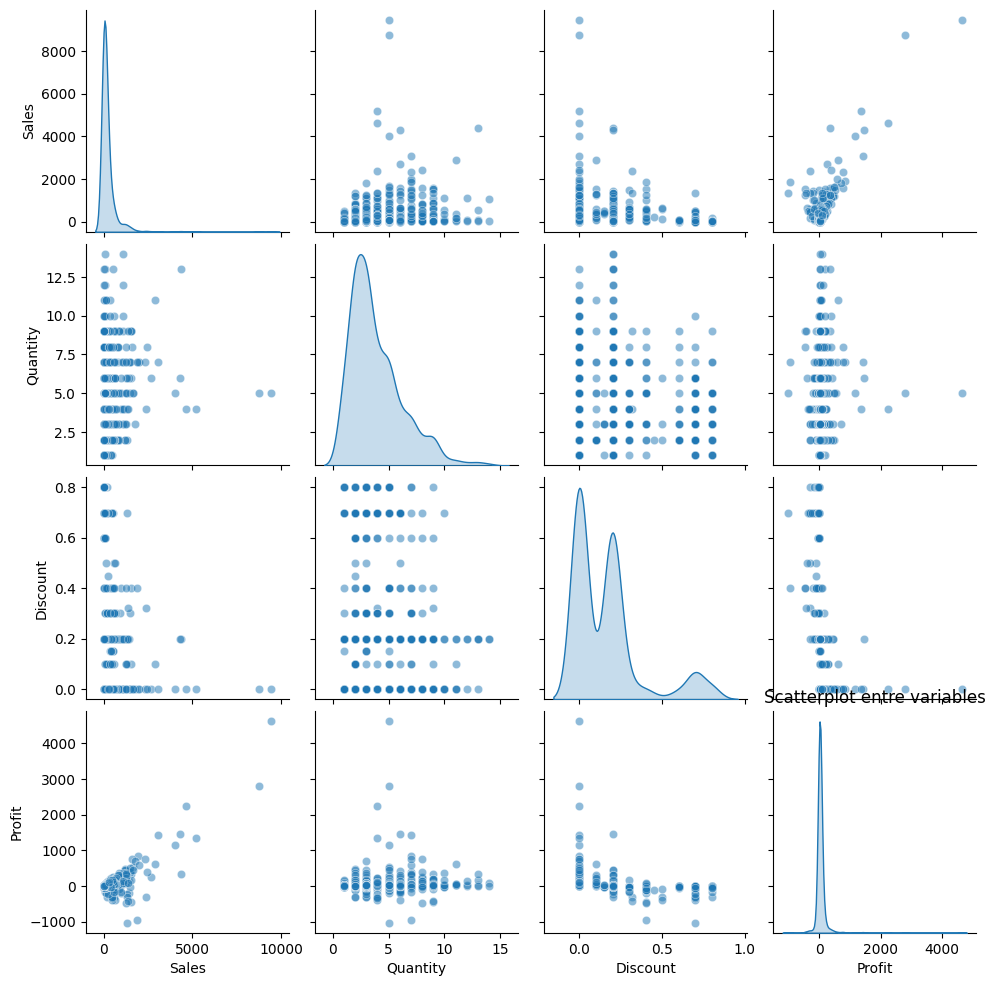

In [132]:
sns.pairplot(show_num.sample(1000, random_state=1), diag_kind='kde', plot_kws={'alpha': 0.5})
plt.title('Scatterplot entre variables')
plt.show()

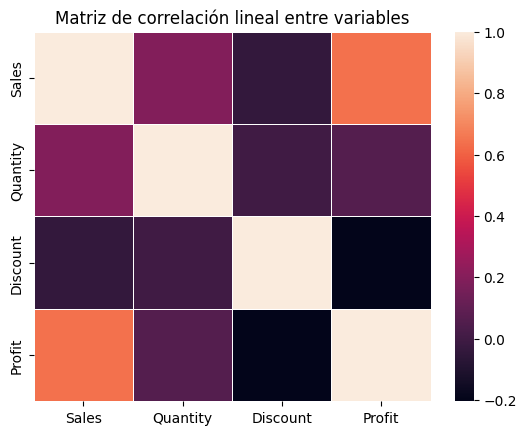

In [133]:
corrmat = show_num.corr()
sns.heatmap(corrmat, vmax=1, linewidths=.5)
plt.title('Matriz de correlación lineal entre variables')
plt.show()

**Estandarización/escalado de datos.**

In [134]:
# Escalado de X
numeric_cols = [
    'Sales', 'Quantity', 'Discount', 'ship_delay',
    'order_year', 'order_month', 'order_dow', 'order_quarter',
    'ship_year', 'ship_month', 'ship_dow', 'ship_quarter',
    'State',
]

scaler_x = RobustScaler()
X_train[numeric_cols] = scaler_x.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler_x.transform(X_test[numeric_cols])
X_val[numeric_cols] = scaler_x.transform(X_val[numeric_cols])

X_train_np = X_train.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)


# Transformación + escalado de y

y_train_log = np.sign(y_train) * np.log1p(np.abs(y_train))
y_test_log  = np.sign(y_test)  * np.log1p(np.abs(y_test))
y_val_log   = np.sign(y_val)   * np.log1p(np.abs(y_val))

scaler_y = StandardScaler()
y_train_np = scaler_y.fit_transform(y_train_log.values.reshape(-1,1)).ravel().astype(np.float32)
y_test_np  = scaler_y.transform(y_test_log.values.reshape(-1,1)).ravel().astype(np.float32)
y_val_np   = scaler_y.transform(y_val_log.values.reshape(-1,1)).ravel().astype(np.float32)

### Diseño e implementación de la red neuronal

In [135]:
class RegresionNet_PyTorch(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(32, 1)  # salida lineal
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(1)


# Configuración de entrenamiento
input_dim = X_train.shape[1]
modelo_reg_pt = RegresionNet_PyTorch(input_dim)

optimizador = optim.Adam(modelo_reg_pt.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=10)

**Comparación MSE, MAE y Huber Loss en el contexto de la distribución de Profit.**

In [136]:
def entrenar_con_loss(loss_fn):
    modelo = RegresionNet_PyTorch(input_dim)
    optimizador = optim.Adam(modelo.parameters(), lr=1e-3)

    X_tr = torch.tensor(X_train_np)
    y_tr = torch.tensor(y_train_np)

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

    for _ in range(50):
        modelo.train()
        for xb, yb in loader:
            pred = modelo(xb)
            loss = loss_fn(pred, yb)

            optimizador.zero_grad()
            loss.backward()
            optimizador.step()

    return modelo

In [144]:
modelo_mse   = entrenar_con_loss(nn.MSELoss())
modelo_mae   = entrenar_con_loss(nn.L1Loss())
modelo_huber = entrenar_con_loss(nn.HuberLoss(delta=5))

In [145]:
def evaluar(modelo):
    modelo.eval()
    with torch.no_grad():
        pred_scaled = modelo(torch.tensor(X_test_np, dtype=torch.float32)).numpy()

    pred_log = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).ravel()
    pred_usd = np.sign(pred_log) * np.expm1(np.abs(pred_log))

    real_usd = np.sign(y_test_log) * np.expm1(np.abs(y_test_log))

    return mean_absolute_error(real_usd, pred_usd)

print("MAE con MSE  :", evaluar(modelo_mse))
print("MAE con MAE  :", evaluar(modelo_mae))
print("MAE con Huber:", evaluar(modelo_huber))

MAE con MSE  : 80.8239934479006
MAE con MAE  : 52.79254230062792
MAE con Huber: 57.744630622337915


### Entrenamiento y curvas de aprendizaje

In [139]:
def entrenar(modelo, X_train, y_train, X_val, y_val,
             epochs=300, batch_size=64, patience=20):

    X_tr = torch.tensor(X_train)
    y_tr = torch.tensor(y_train)
    X_v  = torch.tensor(X_val)
    y_v  = torch.tensor(y_val)

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

    criterio = nn.HuberLoss(delta=5)

    historial_train = []
    historial_val = []

    best_loss = float('inf')
    best_weights = None
    sin_mejora = 0

    for _ in range(epochs):
        modelo.train()
        loss_epoch = 0

        for xb, yb in loader:
            pred = modelo(xb)
            loss = criterio(pred, yb)

            optimizador.zero_grad()
            loss.backward()
            optimizador.step()

            loss_epoch += loss.item()

        loss_train = loss_epoch / len(loader)

        modelo.eval()
        with torch.no_grad():
            loss_val = criterio(modelo(X_v), y_v).item()

        scheduler.step(loss_val)

        historial_train.append(loss_train)
        historial_val.append(loss_val)

        if loss_val < best_loss:
            best_loss = loss_val
            best_weights = copy.deepcopy(modelo.state_dict())
            sin_mejora = 0
        else:
            sin_mejora += 1

        if sin_mejora >= patience:
            break

    modelo.load_state_dict(best_weights)

    return historial_train, historial_val


hist_train, hist_val = entrenar(
    modelo_reg_pt,
    X_train_np, y_train_np,
    X_val_np,  y_val_np
)

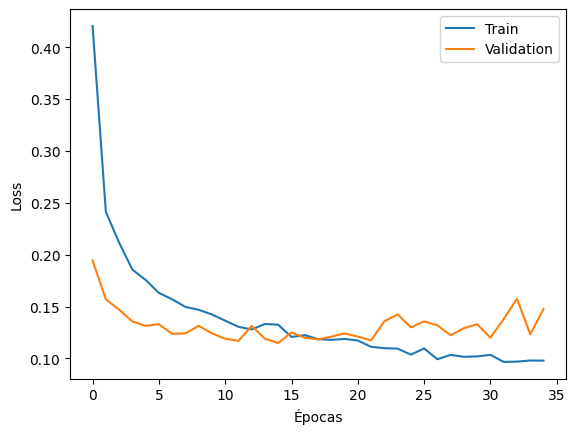

In [140]:
plt.plot(hist_train, label='Train')
plt.plot(hist_val, label='Validation')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Evaluación del modelo

In [141]:
# Predicción
modelo_reg_pt.eval()
with torch.no_grad():
    y_pred_scaled = modelo_reg_pt(torch.tensor(X_test_np, dtype=torch.float32)).numpy()

y_pred_log = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

y_pred_usd = np.sign(y_pred_log) * (np.expm1(np.abs(y_pred_log)))

y_test_usd = np.sign(y_test_log) * (np.expm1(np.abs(y_test_log)))

# Métricas
mse  = mean_squared_error(y_test_usd, y_pred_usd)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_usd, y_pred_usd)
r2   = r2_score(y_test_usd, y_pred_usd)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2:   {r2:.4f}")

MSE:  253893.62
RMSE: 503.88
MAE:  50.06
R2:   -4.2365


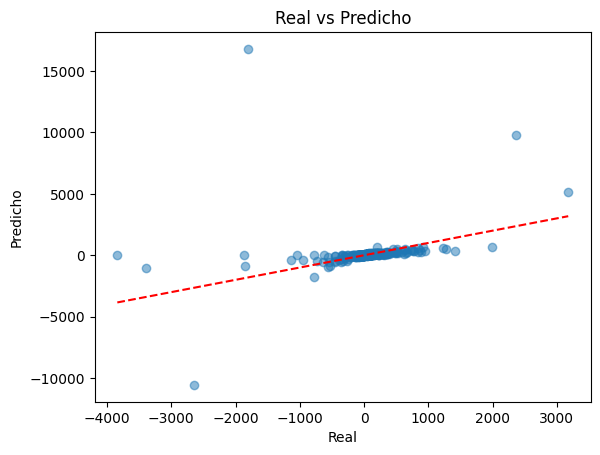

In [142]:
plt.scatter(y_test_usd, y_pred_usd, alpha=0.5)
plt.plot([y_test_usd.min(), y_test_usd.max()],
         [y_test_usd.min(), y_test_usd.max()], 'r--')
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.show()

### Análisis de residuos

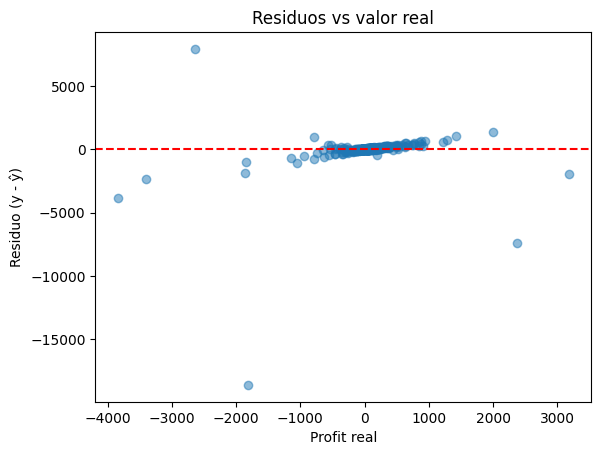

In [143]:
residuos  = y_test_usd - y_pred_usd
error_abs = np.abs(residuos)

plt.scatter(y_test_usd, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Profit real')
plt.ylabel('Residuo (y - ŷ)')
plt.title('Residuos vs valor real')
plt.show()

### Análisis y conclusiones